# Лояльная аудитория ВК: госпаблики vs обычные сообщества

Ноутбук считает статистику по выгрузке из `vk-parser/data` и строит графики.
Для прогона на чистовых данных достаточно поменять **`DATA`** в ячейке конфига —
остальные ячейки не трогаются.

Источники:

| Файл | Что берём |
|---|---|
| `wall_owners.csv` | сообщества: `members_count`, **`is_gov`** (0/1, размечается вручную) |
| `posts.csv` | число постов на сообщество |
| `likes.csv` | лайки + флаг `is_subscribed` (подписчик ли лайкнувший) |
| `comments.csv` | комментарии + `is_subscribed` |
| `users.xlsx` | активность пользователя: `likes_count`, `comments_count` → **ядро** |

> **Оговорки по текущей (промежуточной) выгрузке** — проверено пересчётом на реальных файлах:
>
> - Посты собраны **не для всех сообществ**: 1 067 627 постов лежат всего в **2 557** из
>   6 135 сообществ. Метрики «на пост» считаются только там, где посты есть.
> - «Подписок на сообщества» (сумма `members_count` = 4 365 462) — это **не люди**: один
>   человек подписан на несколько сообществ. Уникальная аудитория считается по `user_id`
>   в лайках и комментариях (≈ 347 тыс.).
> - `is_gov` пока **все нули** — панели Б и В по госпабликам честно покажут «нет данных»,
>   пока вы не проставите единицы.

## 1. Конфиг — единственная ячейка, которую правят руками

In [1]:
from pathlib import Path

# ── Данные ────────────────────────────────────────────────────────────────
DATA = Path('../vk-parser/data')   # ← чистовые данные: поменять только этот путь
FIG  = Path('figures')             # PNG графиков
TAB  = Path('tables')              # сводные таблицы (CSV)
CACHE = Path('cache')              # кэш агрегатов (parquet), чтобы не перечитывать 650 МБ

# ── Ядро аудитории ────────────────────────────────────────────────────────
# Ядро = (лайков > LIKE_THRESHOLD) [AND|OR] (комментариев > COMMENT_THRESHOLD).
# Пороги те же, что у парсера (LIKE_THRESHOLD/COMMENT_THRESHOLD/CORE_COMBINE).
LIKE_THRESHOLD    = 1
COMMENT_THRESHOLD = 1
CORE_COMBINE      = 'and'          # 'and' | 'or'

# ── Категории размера сообществ (по числу подписчиков) ────────────────────
SIZE_BINS   = [0, 100, 1_000, 5_000, 20_000, 100_000, float('inf')]
SIZE_LABELS = ['<100', '100–1K', '1K–5K', '5K–20K', '20K–100K', '100K+']

USE_CACHE = True                   # False — пересчитать агрегаты с нуля

for d in (FIG, TAB, CACHE):
    d.mkdir(exist_ok=True)
print('данные:', DATA.resolve())

данные: /home/plombir1917/code/loyal-audience/vk-parser/data


## 2. Оформление графиков

Палитра прогнана через валидатор (CVD-разделение ΔE 96.7 при пороге 12), поэтому
гос/обычные различимы и при дальтонизме, и в ч/б печати. Метрики разного масштаба
**никогда не кладём на две оси** — только отдельными панелями.

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

GOV   = '#eb6834'   # госпаблики
ORD   = '#2a78d6'   # обычные сообщества
ACC   = '#1baf7a'   # ядро / акцент
INK   = '#0b0b0b'
INK2  = '#52514e'
GRID  = '#e3e2df'

mpl.rcParams.update({
    'figure.facecolor':  '#fcfcfb',
    'axes.facecolor':    '#fcfcfb',
    'savefig.facecolor': '#fcfcfb',
    'savefig.dpi': 150, 'figure.dpi': 110,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'text.color': INK, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2,
    'axes.edgecolor': GRID, 'axes.linewidth': 1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'legend.frameon': False,
})

def label_bars(ax, bars, fmt='{:.0f}', dy=0.01):
    """Подписи прямо на столбцах — цифры читаются без сверки с осью."""
    top = max([b.get_height() for b in bars] + [0]) or 1
    for b in bars:
        h = b.get_height()
        if np.isnan(h):
            continue
        ax.text(b.get_x() + b.get_width()/2, h + top*dy, fmt.format(h),
                ha='center', va='bottom', fontsize=9, color=INK2)

def no_data(ax, msg='нет данных'):
    ax.text(0.5, 0.5, msg, transform=ax.transAxes, ha='center', va='center',
            color=INK2, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

def save(fig, name):
    fig.savefig(FIG / f'{name}.png', bbox_inches='tight')
    print('сохранено:', FIG / f'{name}.png')

## 3. Загрузка и агрегация

`posts.csv` — 650 МБ, поэтому читаем его чанками и **без колонки `text`**.
Результат кэшируется в `cache/*.parquet`.

In [3]:
# ── Сообщества ────────────────────────────────────────────────────────────
owners = pd.read_csv(DATA/'wall_owners.csv', sep=';')
if 'is_gov' not in owners.columns:
    owners['is_gov'] = 0     # столбец ещё не размечен
owners['is_gov'] = pd.to_numeric(owners['is_gov'], errors='coerce').fillna(0).astype(int)
owners['members_count'] = pd.to_numeric(owners['members_count'], errors='coerce').fillna(0).astype('int64')
owners = owners[['owner_id', 'name', 'screen_name', 'members_count', 'is_gov']]

print(f'сообществ: {len(owners):,} | госпабликов: {owners.is_gov.sum():,} '
      f'| подписчиков суммарно: {owners.members_count.sum():,}')
owners.head(3)

сообществ: 6,135 | госпабликов: 0 | подписчиков суммарно: 4,365,462


,owner_id,name,screen_name,members_count,is_gov
0,-218170073,ЭКОЛОГИ АкрамоВО,club218170073,17,0
1,-154940659,"Первые | МБОУ 'Акрамовская ООШ'"" | Чувашия""",club154940659,357,0
2,-231878603,Аврора. Магазин машинной вышивки.,aurora_nchb,15,0


In [4]:
# ── Посты: чанками, только нужные колонки ─────────────────────────────────
posts_cache = CACHE/'posts_agg.parquet'
if USE_CACHE and posts_cache.exists():
    posts_agg = pd.read_parquet(posts_cache)
else:
    parts = []
    for chunk in pd.read_csv(DATA/'posts.csv', sep=';', chunksize=1_000_000,
                             usecols=['owner_id', 'post_id', 'likes_count',
                                      'comments_count', 'views_count'],
                             on_bad_lines='skip', low_memory=False):
        for c in ('owner_id', 'likes_count', 'comments_count', 'views_count'):
            chunk[c] = pd.to_numeric(chunk[c], errors='coerce')
        chunk = chunk.dropna(subset=['owner_id'])
        parts.append(chunk.groupby('owner_id').agg(
            posts=('post_id', 'size'),
            likes_declared=('likes_count', 'sum'),
            comments_declared=('comments_count', 'sum'),
            views=('views_count', 'sum'),
        ))
    posts_agg = (pd.concat(parts).groupby(level=0).sum().reset_index())
    posts_agg['owner_id'] = posts_agg['owner_id'].astype('int64')
    posts_agg.to_parquet(posts_cache)

print(f'постов всего: {posts_agg.posts.sum():,} в {len(posts_agg):,} сообществах')
posts_agg.head(3)

постов всего: 1,067,627 в 2,557 сообществах


,owner_id,posts,likes_declared,comments_declared,views
0,-240076997,2,5.0,0.0,220.0
1,-240003173,6,1.0,12.0,281.0
2,-239914240,9,40.0,6.0,873.0


In [5]:
# ── Лайки: главный источник — здесь есть is_subscribed ────────────────────
likes = pd.read_csv(DATA/'likes.csv', sep=';', usecols=['owner_id', 'user_id', 'is_subscribed'],
                    on_bad_lines='skip', low_memory=False)
likes['owner_id'] = pd.to_numeric(likes['owner_id'], errors='coerce')
likes['user_id']  = pd.to_numeric(likes['user_id'], errors='coerce')
likes = likes.dropna(subset=['owner_id', 'user_id'])
likes['owner_id'] = likes['owner_id'].astype('int64')
likes['user_id']  = likes['user_id'].astype('int64')
likes['is_sub']   = likes['is_subscribed'].astype(str).str.lower().isin(['t', 'true', '1'])

likes_agg = likes.groupby('owner_id').agg(
    likes_total=('user_id', 'size'),
    likes_from_subs=('is_sub', 'sum'),
)
# Уникальные лайкеры: один человек лайкает сообщество много раз — для «доли
# подписчиков, которые ставят лайки» важны люди, а не лайки.
uniq = (likes.drop_duplicates(['owner_id', 'user_id'])
             .groupby('owner_id')
             .agg(unique_likers=('user_id', 'size'), unique_sub_likers=('is_sub', 'sum')))
likes_agg = likes_agg.join(uniq).reset_index()

print(f'лайков: {len(likes):,} | из них от подписчиков: {likes.is_sub.sum():,} '
      f'({likes.is_sub.mean():.1%}) | уникальных лайкеров: {likes.user_id.nunique():,}')
likes_agg.head(3)

лайков: 2,863,597 | из них от подписчиков: 2,090,000 (73.0%) | уникальных лайкеров: 339,318


,owner_id,likes_total,likes_from_subs,unique_likers,unique_sub_likers
0,-240076997,5,5,3,3
1,-240003173,4,0,2,0
2,-239914240,40,36,10,6


In [6]:
# ── Комментарии ───────────────────────────────────────────────────────────
comments = pd.read_csv(DATA/'comments.csv', sep=';', usecols=['owner_id', 'user_id', 'is_subscribed'],
                       on_bad_lines='skip', low_memory=False)
comments['owner_id'] = pd.to_numeric(comments['owner_id'], errors='coerce')
comments['user_id']  = pd.to_numeric(comments['user_id'], errors='coerce')
comments = comments.dropna(subset=['owner_id', 'user_id'])
comments['owner_id'] = comments['owner_id'].astype('int64')
comments['user_id']  = comments['user_id'].astype('int64')
comments['is_sub']   = comments['is_subscribed'].astype(str).str.lower().isin(['t', 'true', '1'])

comments_agg = comments.groupby('owner_id').agg(
    comments_total=('user_id', 'size'),
    comments_from_subs=('is_sub', 'sum'),
    unique_commenters=('user_id', 'nunique'),
).reset_index()

print(f'комментариев: {len(comments):,} | от подписчиков: {comments.is_sub.mean():.1%} '
      f'| уникальных комментаторов: {comments.user_id.nunique():,}')
comments_agg.head(3)

комментариев: 181,994 | от подписчиков: 74.5% | уникальных комментаторов: 36,992


,owner_id,comments_total,comments_from_subs,unique_commenters
0,-239914240,6,6,3
1,-239649948,13,10,12
2,-239629421,1,1,1


In [7]:
# ── Сборка витрины по сообществам ─────────────────────────────────────────
g = (owners.merge(posts_agg, on='owner_id', how='left')
            .merge(likes_agg, on='owner_id', how='left')
            .merge(comments_agg, on='owner_id', how='left'))
num = ['posts', 'likes_declared', 'comments_declared', 'views', 'likes_total', 'likes_from_subs',
       'unique_likers', 'unique_sub_likers', 'comments_total', 'comments_from_subs', 'unique_commenters']
g[num] = g[num].fillna(0)

g['size_bucket'] = pd.cut(g.members_count, bins=SIZE_BINS, labels=SIZE_LABELS, right=False)
g['segment'] = np.where(g.is_gov == 1, 'Госпаблики', 'Обычные')

def safe_div(a, b):
    return np.where(b > 0, a / np.maximum(b, 1), np.nan)

# Метрики на сообщество
g['avg_likes_per_post']    = safe_div(g.likes_total, g.posts)          # средние лайки на пост
g['share_likes_from_subs'] = safe_div(g.likes_from_subs, g.likes_total)  # какая доля лайков — от подписчиков
g['sub_like_reach']        = np.minimum(safe_div(g.unique_sub_likers, g.members_count), 1)  # сколько % подписчиков лайкают

g.to_csv(TAB/'groups.csv', index=False)
print(f'витрина: {len(g):,} сообществ')
g[['name', 'members_count', 'is_gov', 'size_bucket', 'posts', 'likes_total',
   'avg_likes_per_post', 'share_likes_from_subs', 'sub_like_reach']].head(5)

витрина: 6,135 сообществ


,name,members_count,is_gov,size_bucket,posts,likes_total,avg_likes_per_post,share_likes_from_subs,sub_like_reach
0,ЭКОЛОГИ АкрамоВО,17,0,<100,0.0,0.0,NaN,NaN,0.000000
1,"Первые | МБОУ 'Акрамовская ООШ'"" | Чувашия""",357,0,100–1K,59.0,873.0,14.796610,0.875143,0.207283
2,Аврора. Магазин машинной вышивки.,15,0,<100,22.0,6.0,0.272727,0.333333,0.066667
3,"Фитнес-центр 'Шоколад'"" Новочебоксарск""",680,0,100–1K,0.0,0.0,NaN,NaN,0.000000
4,Автосервис CarService Новочебоксарск,48,0,<100,0.0,0.0,NaN,NaN,0.000000


In [8]:
# ── Пользователи и ядро ───────────────────────────────────────────────────
users = pd.read_excel(DATA/'users.xlsx')
users['likes_count']    = pd.to_numeric(users['likes_count'], errors='coerce').fillna(0)
users['comments_count'] = pd.to_numeric(users['comments_count'], errors='coerce').fillna(0)

by_likes    = users.likes_count > LIKE_THRESHOLD
by_comments = users.comments_count > COMMENT_THRESHOLD
users['is_core'] = (by_likes & by_comments) if CORE_COMBINE == 'and' else (by_likes | by_comments)

print(f'пользователей: {len(users):,} | ядро: {users.is_core.sum():,} ({users.is_core.mean():.1%}) '
      f'[лайков > {LIKE_THRESHOLD} {CORE_COMBINE.upper()} комментариев > {COMMENT_THRESHOLD}]')
users.head(3)

пользователей: 347,345 | ядро: 12,071 (3.5%) [лайков > 1 AND комментариев > 1]


,user_id,profile_url,likes_count,likes_share_percent,comments_count,comments_share_percent,is_core
0,331183854,https://vk.com/id331183854,9378,0.327,0,0.000,False
1,98909329,https://vk.com/id98909329,3542,0.123,0,0.000,False
2,591587922,https://vk.com/id591587922,3483,0.121,93,0.051,True


## 4. Агрегаты по категориям размера

Доли считаются **пулом** (сумма/сумма внутри корзины), а не средним по средним:
иначе паблик на 17 подписчиков весит столько же, сколько паблик на 100 тысяч.

In [9]:
def by_bucket(df):
    b = df.groupby('size_bucket', observed=False).agg(
        groups=('owner_id', 'size'),
        members=('members_count', 'sum'),
        posts=('posts', 'sum'),
        likes=('likes_total', 'sum'),
        likes_subs=('likes_from_subs', 'sum'),
        uniq_sub_likers=('unique_sub_likers', 'sum'),
    )
    b['avg_likes_per_post']    = safe_div(b.likes, b.posts)
    b['share_likes_from_subs'] = safe_div(b.likes_subs, b.likes)
    b['sub_like_reach']        = np.minimum(safe_div(b.uniq_sub_likers, b.members), 1)
    return b

buckets = by_bucket(g)
buckets.to_csv(TAB/'by_size_bucket.csv')
buckets[['groups', 'members', 'posts', 'avg_likes_per_post', 'share_likes_from_subs', 'sub_like_reach']]

,groups,members,posts,avg_likes_per_post,share_likes_from_subs,sub_like_reach
size_bucket,,,,,,
<100,3173,116531,18038.0,2.464131,0.682910,0.033133
100–1K,2154,747415,126431.0,5.985684,0.783870,0.060820
1K–5K,658,1412711,820069.0,1.514932,0.783548,0.060189
5K–20K,132,1190086,51953.0,13.140589,0.589262,0.046324
20K–100K,17,773054,17342.0,6.370142,0.820650,0.024135
100K+,1,125665,652.0,30.208589,0.000000,0.000000


## А) Средние лайки и доля подписчиков по размеру сообществ

Читается так: «в сообществах 5K–20K в среднем N лайков на пост, из них M% ставят
подписчики, а лайкает K% всех подписчиков сообщества».

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


сохранено: figures/A_engagement_by_size.png


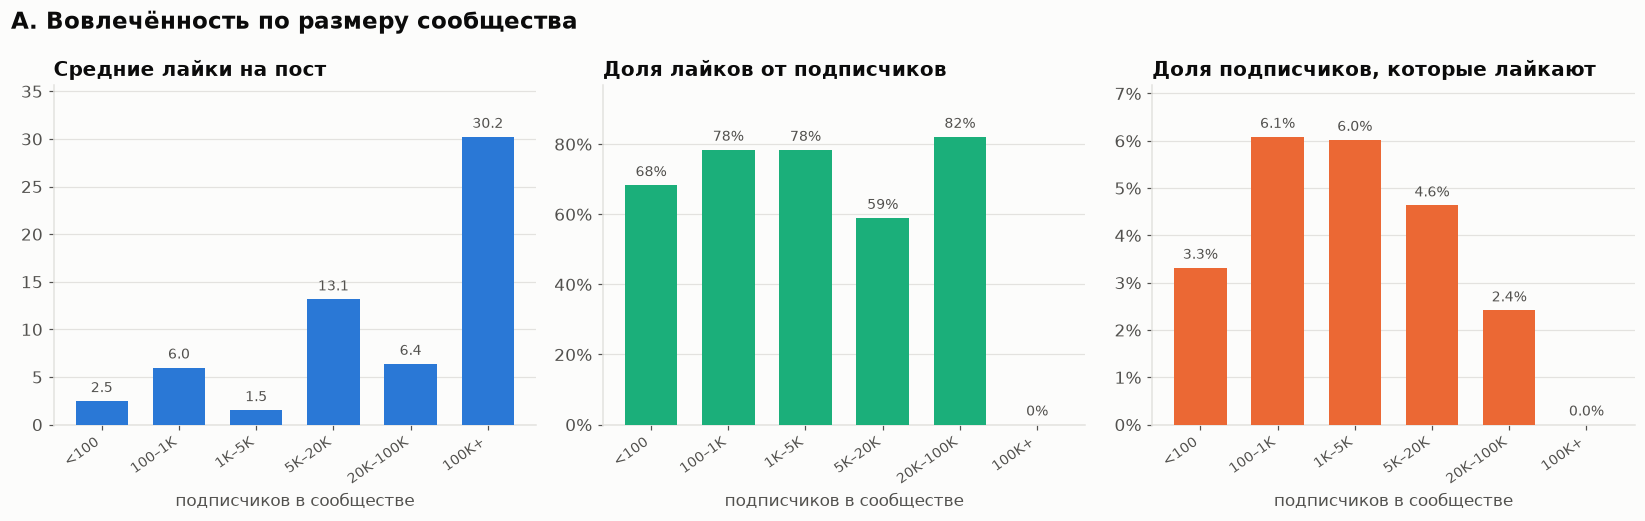

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
x = np.arange(len(SIZE_LABELS))

panels = [
    ('avg_likes_per_post',    'Средние лайки на пост',             '{:.1f}', False, ORD),
    ('share_likes_from_subs', 'Доля лайков от подписчиков',        '{:.0%}', True,  ACC),
    ('sub_like_reach',        'Доля подписчиков, которые лайкают', '{:.1%}', True,  GOV),
]
for ax, (col, title, fmt, is_pct, color) in zip(axes, panels):
    vals = buckets[col].values
    bars = ax.bar(x, vals, color=color, width=0.68, zorder=3)
    ax.set_title(title, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(SIZE_LABELS, rotation=35, ha='right', fontsize=9)  # иначе 5K–20K и 20K–100K налезают
    ax.set_xlabel('подписчиков в сообществе')
    ax.xaxis.grid(False)
    if is_pct:
        ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
    top = np.nanmax(vals) if np.nanmax(vals) > 0 else 1
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x()+b.get_width()/2, v + top*0.02, fmt.format(v),
                    ha='center', va='bottom', fontsize=9, color=INK2)
    ax.set_ylim(0, top*1.18)

fig.suptitle('А. Вовлечённость по размеру сообщества', x=0.005, ha='left', fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'A_engagement_by_size')

## Б) То же самое: госпаблики vs обычные

Слева — госпаблики, справа — обычные. Оси в каждой строке общие, поэтому высоты
столбцов сравнимы напрямую.

findfont: Failed to find font weight semibold, now using 700.


сохранено: figures/B_gov_vs_ordinary.png


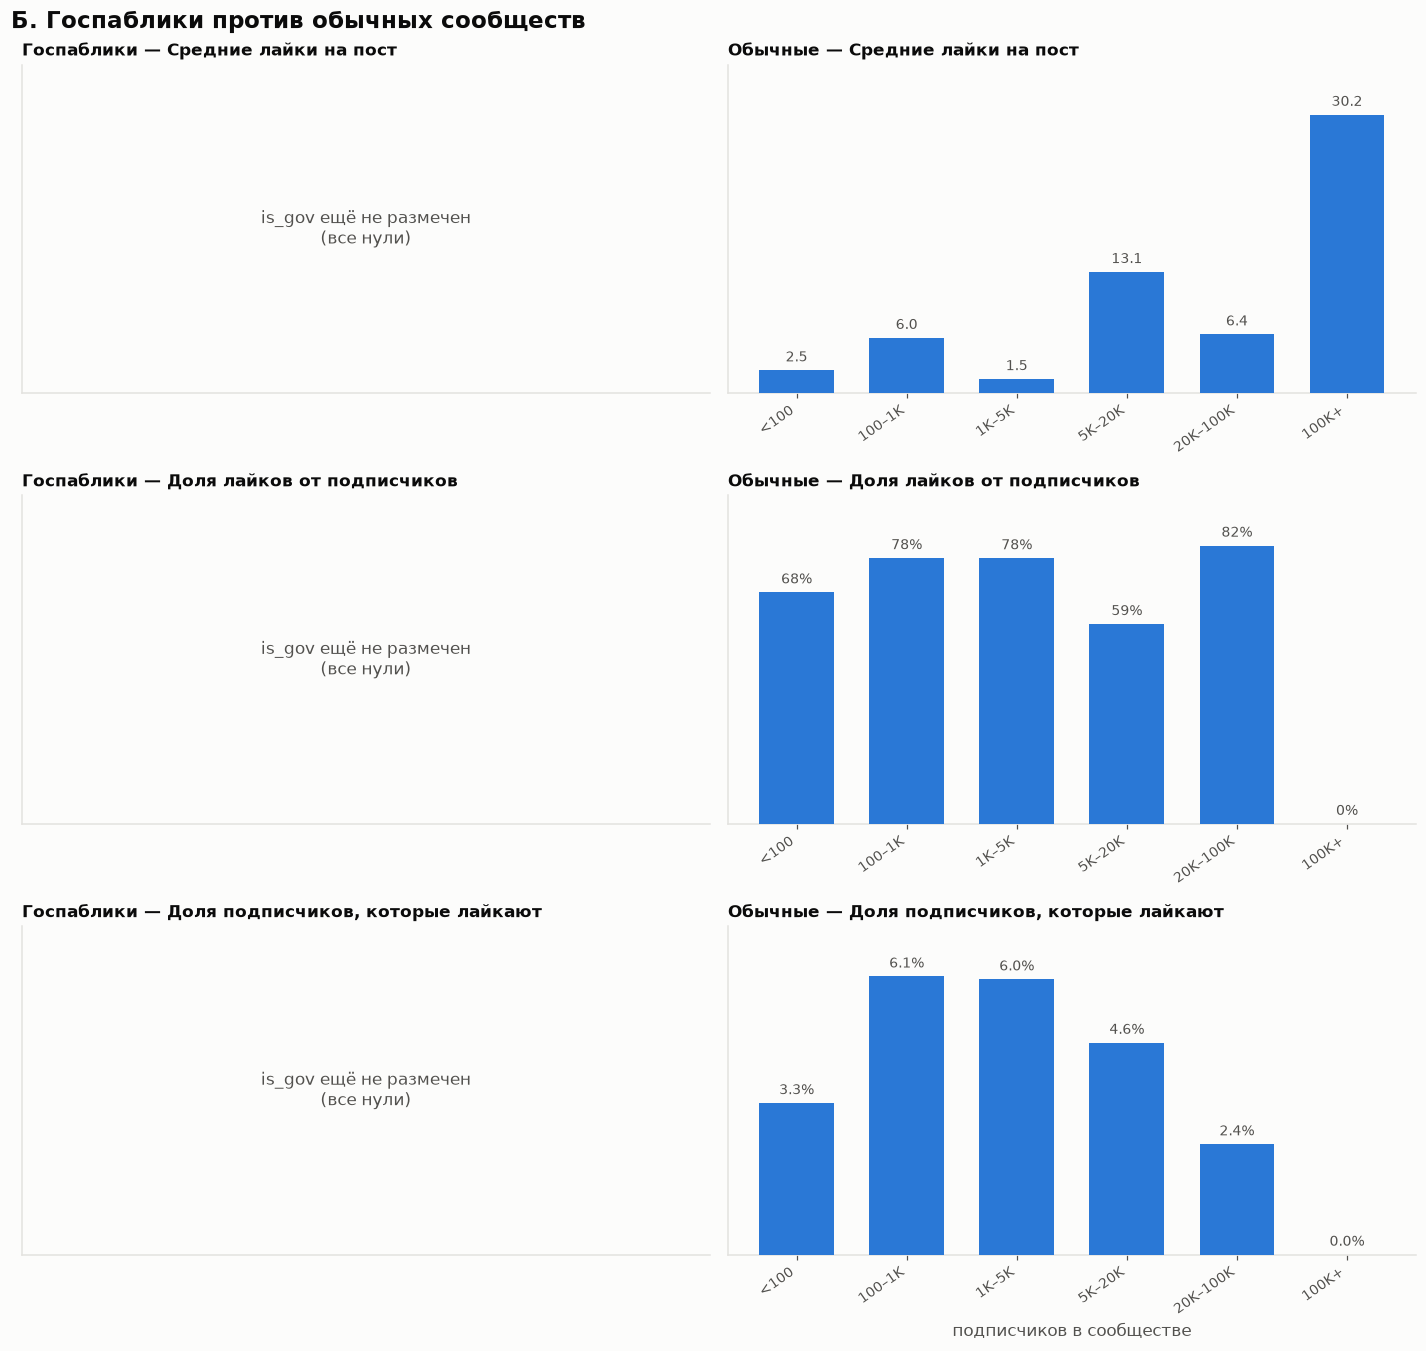

In [11]:
gov_b = by_bucket(g[g.is_gov == 1])
ord_b = by_bucket(g[g.is_gov == 0])
n_gov = int((g.is_gov == 1).sum())

fig, axes = plt.subplots(3, 2, figsize=(13, 12.5), sharey='row')
cols = [
    ('avg_likes_per_post',     'Средние лайки на пост',             '{:.1f}', False),
    ('share_likes_from_subs',  'Доля лайков от подписчиков',        '{:.0%}', True),
    ('sub_like_reach',         'Доля подписчиков, которые лайкают', '{:.1%}', True),
]
for row, (col, title, fmt, is_pct) in enumerate(cols):
    for i, (bdf, label, color) in enumerate([(gov_b, 'Госпаблики', GOV), (ord_b, 'Обычные', ORD)]):
        ax = axes[row, i]
        if label == 'Госпаблики' and n_gov == 0:
            no_data(ax, 'is_gov ещё не размечен\n(все нули)')
            ax.set_title(f'{label} — {title}', loc='left', fontsize=11)
            continue
        vals = bdf[col].values
        bars = ax.bar(x, vals, color=color, width=0.68, zorder=3)
        ax.set_title(f'{label} — {title}', loc='left', fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(SIZE_LABELS, rotation=35, ha='right', fontsize=9)
        ax.xaxis.grid(False)
        if is_pct:
            ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
        both = np.concatenate([gov_b[col].values, ord_b[col].values]) if n_gov else vals
        top = np.nanmax(both) if np.nanmax(both) > 0 else 1
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x()+b.get_width()/2, v + top*0.02, fmt.format(v),
                        ha='center', va='bottom', fontsize=9, color=INK2)
        ax.set_ylim(0, top*1.18)
        if row == 2:
            ax.set_xlabel('подписчиков в сообществе')

fig.suptitle('Б. Госпаблики против обычных сообществ', x=0.005, ha='left', fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'B_gov_vs_ordinary')

## В) Аудитория и ядро

Сколько людей вообще интересуются медийкой региона, сколько из них — ядро, и
сколько ядра сидит в сетке госпабликов.

сохранено: figures/C_audience_core.png


,показатель,значение
0,Подписок на сообщества (с повторами),4365462
1,Подписок на госпаблики,0
2,Уникальная аудитория (след в данных),346700
3,Ядро,12071
4,Доля ядра в аудитории,3.5%
5,Аудитория госпабликов,0
6,"Ядро, лайкающее госпаблики",0
7,Доля ядра в госпабликах,0.0%


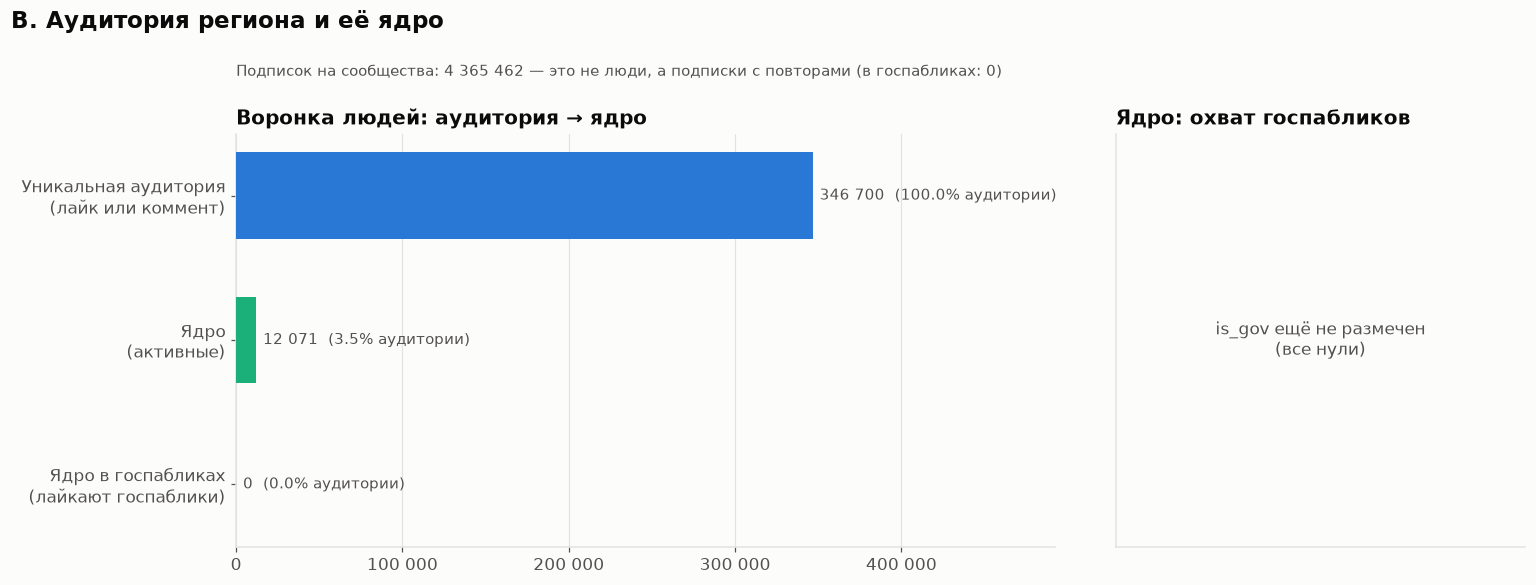

In [12]:
gov_ids = set(g.loc[g.is_gov == 1, 'owner_id'])

core_ids      = set(users.loc[users.is_core, 'user_id'])
audience_ids  = set(likes.user_id) | set(comments.user_id)      # оставили хоть какой-то след
gov_liker_ids = set(likes.loc[likes.owner_id.isin(gov_ids), 'user_id']) if gov_ids else set()
gov_core_ids  = gov_liker_ids & core_ids

subs_total = int(g.members_count.sum())
subs_gov   = int(g.loc[g.is_gov == 1, 'members_count'].sum())

def rus(n):
    return f'{n:,.0f}'.replace(',', ' ')

# Воронка строится ТОЛЬКО по людям. Сумма подписок (4.3 млн) — это не люди, а
# подписки с повторами; на одной оси с ядром она сплющила бы всё в невидимую линию,
# поэтому она вынесена в число-контекст над воронкой.
stages = ['Уникальная аудитория\n(лайк или коммент)', 'Ядро\n(активные)',
          'Ядро в госпабликах\n(лайкают госпаблики)']
values = [len(audience_ids), len(core_ids), len(gov_core_ids)]
colors = [ORD, ACC, GOV]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={'width_ratios': [2, 1]})

bars = ax1.barh(stages[::-1], values[::-1], color=colors[::-1], height=0.6, zorder=3)
ax1.set_title('Воронка людей: аудитория → ядро', loc='left')
ax1.yaxis.grid(False)
ax1.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: rus(v)))
base = max(values[0], 1)
for b, v in zip(bars, values[::-1]):
    share = v / base
    ax1.text(v + base*0.012, b.get_y()+b.get_height()/2,
             f'{rus(v)}  ({share:.1%} аудитории)', va='center', fontsize=10, color=INK2)
ax1.set_xlim(0, base*1.42)
ax1.text(0, 1.14, f'Подписок на сообщества: {rus(subs_total)} — это не люди, '
                  f'а подписки с повторами (в госпабликах: {rus(subs_gov)})',
         transform=ax1.transAxes, fontsize=10, color=INK2)

# Ядро: где оно сидит
if gov_ids:
    parts  = [len(gov_core_ids), len(core_ids) - len(gov_core_ids)]
    labels = ['Ядро,\nлайкает госпаблики', 'Ядро,\nтолько обычные']
    b2 = ax2.bar([0, 1], parts, color=[GOV, ACC], width=0.6, zorder=3)
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(labels, fontsize=9)
    ax2.set_title('Ядро: охват госпабликов', loc='left')
    ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: rus(v)))
    for b, v in zip(b2, parts):
        ax2.text(b.get_x()+b.get_width()/2, v + max(parts)*0.02, rus(v),
                 ha='center', va='bottom', fontsize=9, color=INK2)
    ax2.xaxis.grid(False)
else:
    no_data(ax2, 'is_gov ещё не размечен\n(все нули)')
    ax2.set_title('Ядро: охват госпабликов', loc='left')

fig.suptitle('В. Аудитория региона и её ядро', x=0.005, ha='left', fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'C_audience_core')

summary = pd.DataFrame({
    'показатель': ['Подписок на сообщества (с повторами)', 'Подписок на госпаблики',
                   'Уникальная аудитория (след в данных)', 'Ядро', 'Доля ядра в аудитории',
                   'Аудитория госпабликов', 'Ядро, лайкающее госпаблики', 'Доля ядра в госпабликах'],
    'значение': [subs_total, subs_gov, len(audience_ids), len(core_ids),
                 f'{len(core_ids)/max(len(audience_ids),1):.1%}',
                 len(gov_liker_ids), len(gov_core_ids),
                 f'{len(gov_core_ids)/max(len(core_ids),1):.1%}'],
})
summary.to_csv(TAB/'summary.csv', index=False)
summary

## Дополнительно: структура выгрузки

сохранено: figures/D_structure.png


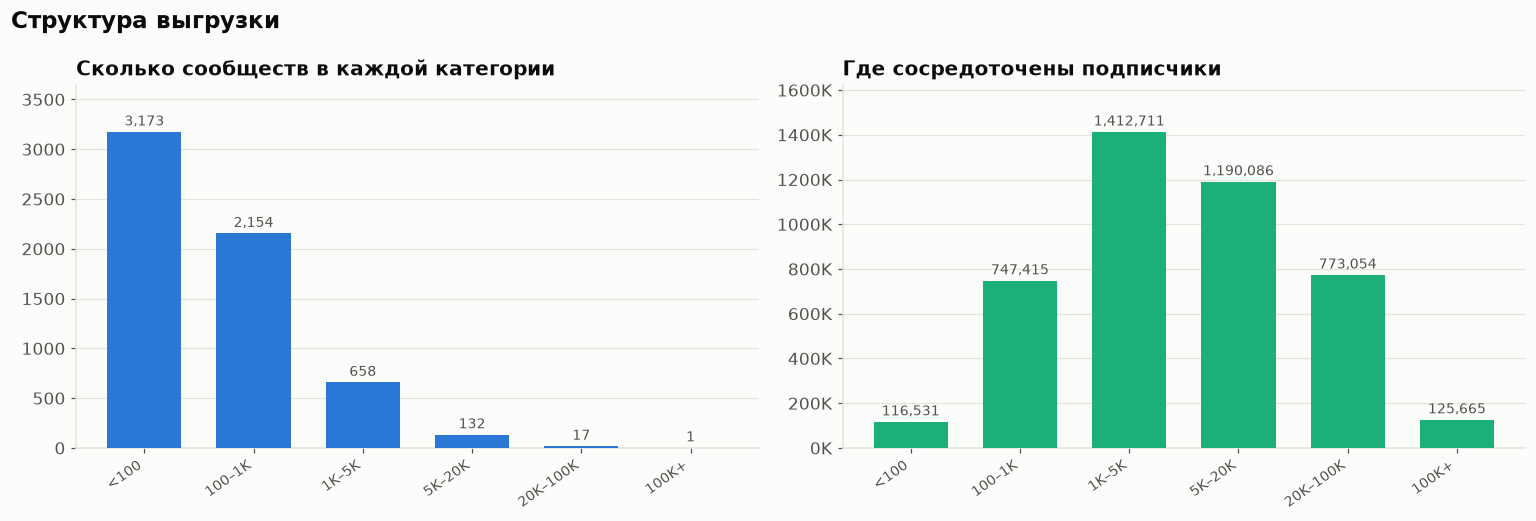

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

cnt = g.groupby('size_bucket', observed=False).size()
b1 = ax1.bar(x, cnt.values, color=ORD, width=0.68, zorder=3)
ax1.set_title('Сколько сообществ в каждой категории', loc='left')
ax1.set_xticks(x); ax1.set_xticklabels(SIZE_LABELS, rotation=35, ha='right', fontsize=9)
ax1.xaxis.grid(False)
label_bars(ax1, b1, '{:,.0f}')
ax1.set_ylim(0, cnt.max()*1.15)

mem = g.groupby('size_bucket', observed=False).members_count.sum()
b2 = ax2.bar(x, mem.values, color=ACC, width=0.68, zorder=3)
ax2.set_title('Где сосредоточены подписчики', loc='left')
ax2.set_xticks(x); ax2.set_xticklabels(SIZE_LABELS, rotation=35, ha='right', fontsize=9)
ax2.xaxis.grid(False)
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
label_bars(ax2, b2, '{:,.0f}')
ax2.set_ylim(0, mem.max()*1.15)

fig.suptitle('Структура выгрузки', x=0.005, ha='left', fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'D_structure')

In [14]:
# Топ-15 сообществ по вовлечённости (среди тех, где есть посты и подписчики)
top = (g[(g.posts > 0) & (g.members_count >= 100)]
       .nlargest(15, 'likes_total')
       [['name', 'members_count', 'segment', 'posts', 'likes_total',
         'avg_likes_per_post', 'share_likes_from_subs', 'sub_like_reach']])
top.to_csv(TAB/'top_groups.csv', index=False)
top.style.format({'avg_likes_per_post': '{:.1f}', 'share_likes_from_subs': '{:.1%}',
                  'sub_like_reach': '{:.1%}', 'members_count': '{:,.0f}', 'likes_total': '{:,.0f}'})

,name,members_count,segment,posts,likes_total,avg_likes_per_post,share_likes_from_subs,sub_like_reach
223,Администрация Алатырского муниципального округа,"8,054",Обычные,1673.000000,"92,953",55.6,96.1%,41.4%
5839,"МБУ 'ЦБС'"" Чебоксарского муниципального округа""","1,801",Обычные,1734.000000,"64,733",37.3,99.6%,11.2%
31,Подслушано Алатырь,"40,660",Обычные,2044.000000,"61,414",30.0,94.2%,21.9%
224,СМИ г. Алатырь,"16,687",Обычные,4734.000000,"54,042",11.4,0.0%,0.0%
2355,"РАБОТА ВАХТА (Чувашия, Чебоксары)","5,248",Обычные,3453.000000,"49,992",14.5,0.0%,0.0%
2211,Мир книжной змейки,"9,268",Обычные,254.000000,"49,037",193.1,84.6%,22.2%
1830,Вакансии в Чувашии,"12,491",Обычные,3479.000000,"44,504",12.8,0.0%,0.0%
457,АЛАТЫРСКИЙ ТЕХНОЛОГИЧЕСКИЙ КОЛЛЕДЖ,"3,890",Обычные,835.000000,"39,070",46.8,95.8%,22.9%
275,Алатырь КОШКИ / СОБАКИ потеряшки помощь,"2,636",Обычные,692.000000,"37,710",54.5,93.9%,30.4%
1848,"БУ 'Алатырский КЦСОН'""""","1,834",Обычные,335.000000,"33,738",100.7,95.8%,37.4%


## Д) Концентрация активности: кто на самом деле делает лайки

Ключевой вопрос к любому «ядру»: это статистическая случайность или реально
небольшая группа тащит на себе всю активность. Слева — распределение
пользователей по числу лайков (обе оси логарифмические: если распределение
степенное, точки лягут на прямую). Справа — кривая Лоренца: какая доля лайков
приходится на самых активных.

сохранено: figures/E_concentration.png


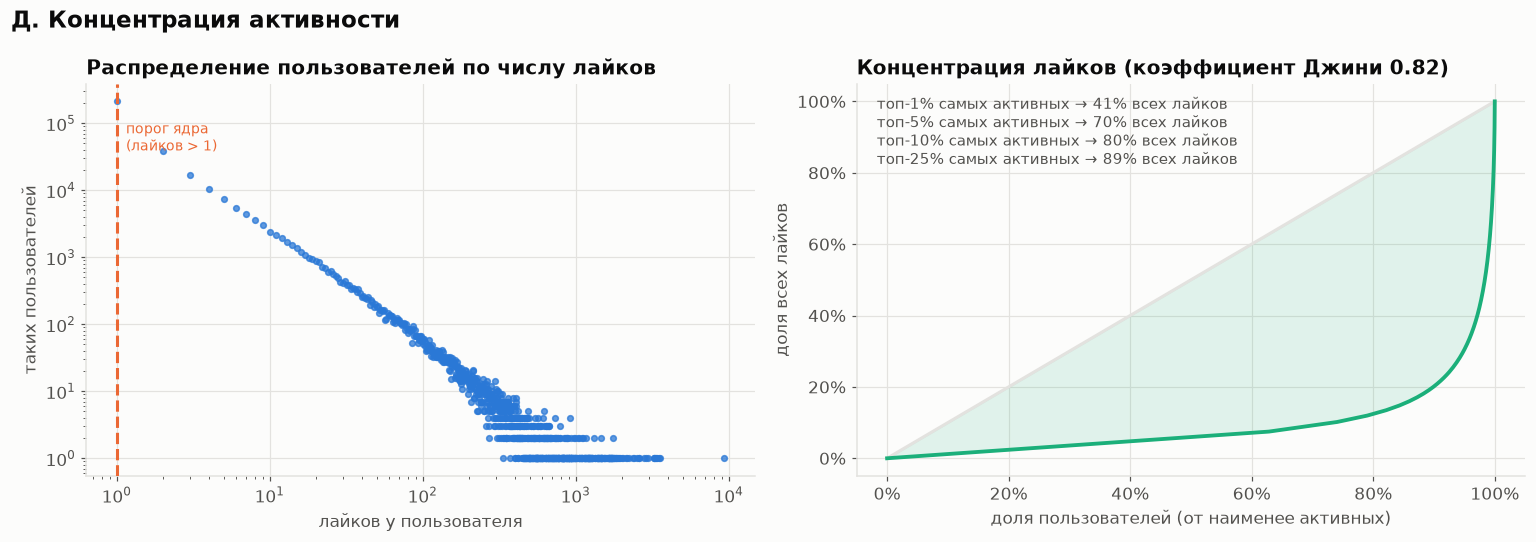

In [15]:
likes_per_user = users.likes_count.values
lpu = np.sort(likes_per_user[likes_per_user > 0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Распределение: сколько людей поставили ровно N лайков ────────────────────
vals, cnts = np.unique(lpu, return_counts=True)
ax1.scatter(vals, cnts, s=14, color=ORD, zorder=3, alpha=0.75)
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('лайков у пользователя'); ax1.set_ylabel('таких пользователей')
ax1.set_title('Распределение пользователей по числу лайков', loc='left')
ax1.axvline(LIKE_THRESHOLD, color=GOV, lw=2, ls='--', zorder=4)
ax1.text(LIKE_THRESHOLD*1.15, cnts.max()*0.5, f'порог ядра\n(лайков > {LIKE_THRESHOLD})',
         color=GOV, fontsize=9, va='top')

# ── Кривая Лоренца: концентрация лайков ─────────────────────────────────────
cum_users = np.arange(1, len(lpu)+1) / len(lpu)
cum_likes = np.cumsum(lpu) / lpu.sum()
gini = 1 - 2*np.trapezoid(cum_likes, cum_users)

ax2.plot([0, 1], [0, 1], color=GRID, lw=2, zorder=2)                     # равномерное распределение
ax2.plot(cum_users, cum_likes, color=ACC, lw=2.5, zorder=3, label='Факт')
ax2.fill_between(cum_users, cum_likes, cum_users, color=ACC, alpha=0.12, zorder=1)
ax2.set_xlabel('доля пользователей (от наименее активных)')
ax2.set_ylabel('доля всех лайков')
ax2.set_title(f'Концентрация лайков (коэффициент Джини {gini:.2f})', loc='left')
ax2.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax2.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))

# Сколько лайков дают самые активные N%
lines = []
for top in (0.01, 0.05, 0.10, 0.25):
    share = lpu[-int(len(lpu)*top):].sum() / lpu.sum()
    lines.append(f'топ-{top:.0%} самых активных → {share:.0%} всех лайков')
ax2.text(0.03, 0.97, '\n'.join(lines), transform=ax2.transAxes, va='top', fontsize=9.5,
         color=INK2)

fig.suptitle('Д. Концентрация активности', x=0.005, ha='left', fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'E_concentration')

## Е) Насколько ядро устойчиво к порогам

Пороги в ТЗ предварительные (лайков > 1, комментариев > 1) и будут тюниться. Этот
график показывает цену решения: как меняется размер ядра при сдвиге порога по
лайкам — отдельно для строгой формулы (И) и мягкой (ИЛИ). Вертикаль — текущий
выбор.

сохранено: figures/F_core_sensitivity.png


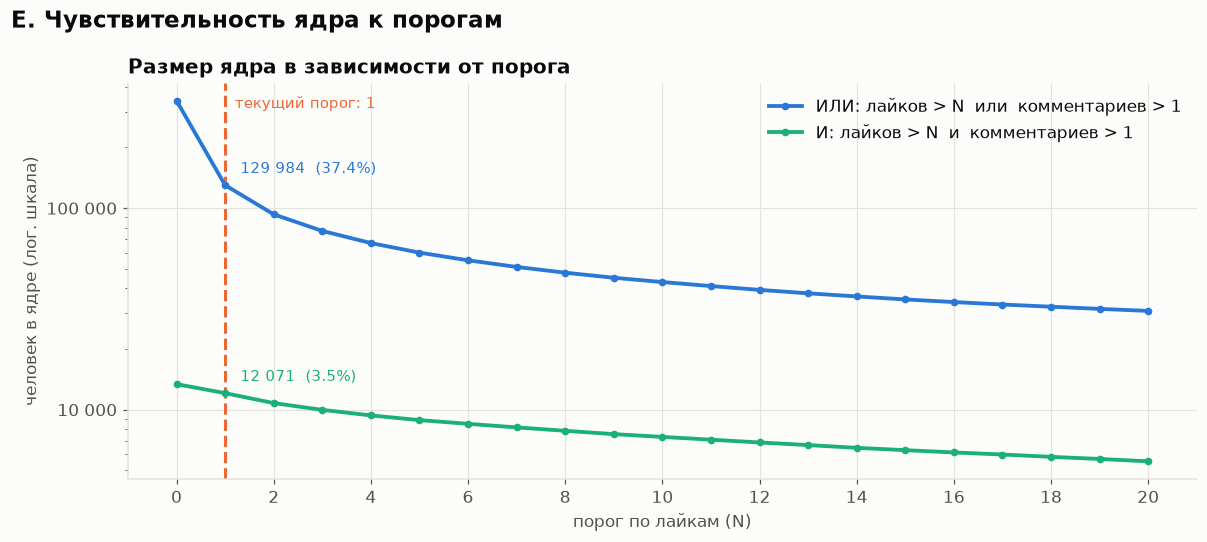

In [16]:
thr_range = np.arange(0, 21)
and_core, or_core = [], []
for t in thr_range:
    by_l = users.likes_count > t
    by_c = users.comments_count > COMMENT_THRESHOLD
    and_core.append(int((by_l & by_c).sum()))
    or_core.append(int((by_l | by_c).sum()))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thr_range, or_core,  color=ORD, lw=2.5, marker='o', ms=4, zorder=3,
        label=f'ИЛИ: лайков > N  или  комментариев > {COMMENT_THRESHOLD}')
ax.plot(thr_range, and_core, color=ACC, lw=2.5, marker='o', ms=4, zorder=3,
        label=f'И: лайков > N  и  комментариев > {COMMENT_THRESHOLD}')
ax.axvline(LIKE_THRESHOLD, color=GOV, lw=2, ls='--', zorder=2)
ax.text(LIKE_THRESHOLD + 0.2, max(or_core)*0.92, f'текущий порог: {LIKE_THRESHOLD}',
        color=GOV, fontsize=10)

ax.set_yscale('log')
ax.set_xlabel('порог по лайкам (N)'); ax.set_ylabel('человек в ядре (лог. шкала)')
ax.set_title('Размер ядра в зависимости от порога', loc='left')
ax.set_xticks(thr_range[::2])
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: rus(v)))
ax.legend(loc='upper right')

# Прямые подписи на текущем пороге — без сверки с осью
for series, color in ((and_core, ACC), (or_core, ORD)):
    v = series[LIKE_THRESHOLD]
    ax.annotate(f'{rus(v)}  ({v/len(users):.1%})', (LIKE_THRESHOLD, v),
                textcoords='offset points', xytext=(10, 8), fontsize=9.5, color=color)

fig.suptitle('Е. Чувствительность ядра к порогам', x=0.005, ha='left', fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'F_core_sensitivity')

## Ж) Вовлечённость против размера сообщества

Категории размера усредняют — здесь каждое сообщество это точка. Видно и общий
тренд, и выбросы: паблики, которые собирают лайки сильно выше своего размера
(кандидаты в лидеры мнений), и «мёртвые» крупные группы.

сохранено: figures/G_engagement_vs_size.png


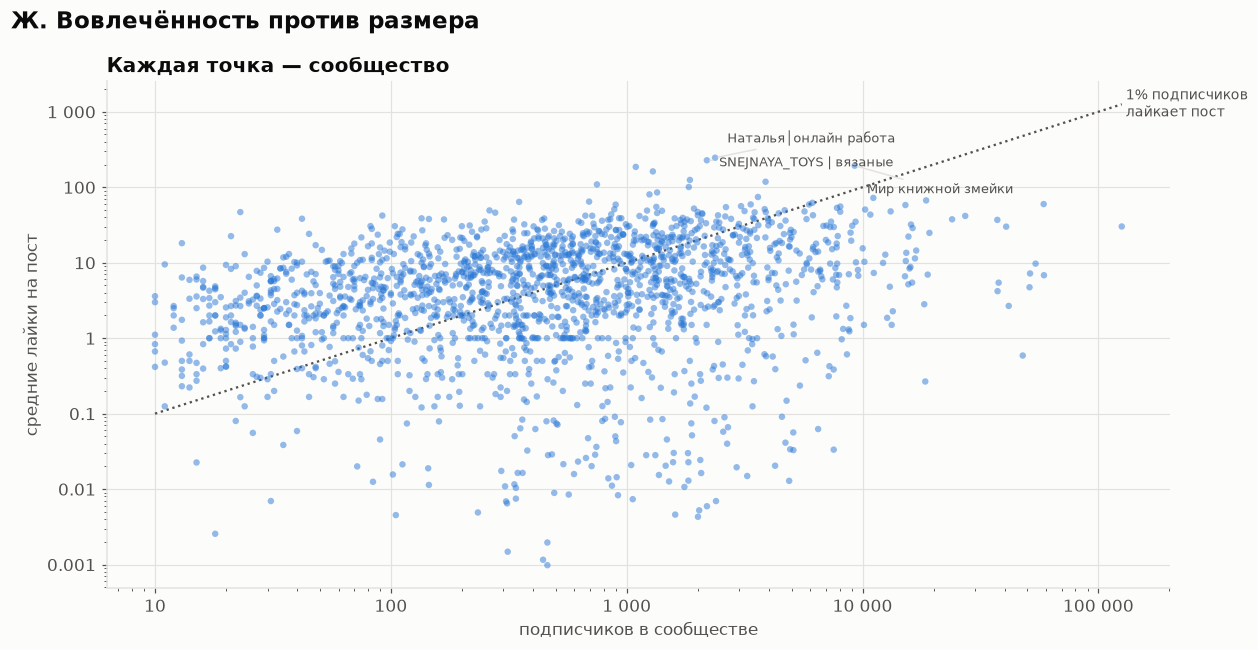

In [17]:
pts = g[(g.posts > 0) & (g.members_count > 0) & (g.likes_total > 0)]

fig, ax = plt.subplots(figsize=(11.5, 6))
for flag, label, color in [(0, 'Обычные', ORD), (1, 'Госпаблики', GOV)]:
    s = pts[pts.is_gov == flag]
    if s.empty:
        continue
    ax.scatter(s.members_count, s.avg_likes_per_post, s=18, alpha=0.5,
               color=color, edgecolors='none', label=label, zorder=3)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('подписчиков в сообществе'); ax.set_ylabel('средние лайки на пост')
ax.set_title('Каждая точка — сообщество', loc='left')
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: rus(v)))
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda v, _: rus(v) if v >= 1 else f'{v:g}'))
if pts.is_gov.nunique() > 1:
    ax.legend(loc='upper left')

# Ориентир: 1% подписчиков лайкает пост
xs = np.array([pts.members_count.min(), pts.members_count.max()])
ax.plot(xs, xs*0.01, color=INK2, lw=1.5, ls=':', zorder=2)
ax.text(xs[1], xs[1]*0.01, ' 1% подписчиков\n лайкает пост', color=INK2, fontsize=9, va='center')

# Подписываем только выбросы — топ-5 по лайкам на пост среди заметных сообществ
top3 = pts[pts.members_count >= 1000].nlargest(3, 'avg_likes_per_post')
for (_, r), dy in zip(top3.iterrows(), (10, -4, -18)):
    ax.annotate(str(r['name'])[:24], (r.members_count, r.avg_likes_per_post),
                textcoords='offset points', xytext=(8, dy), fontsize=8.5, color=INK2,
                arrowprops=dict(arrowstyle='-', color=GRID, lw=1))

fig.suptitle('Ж. Вовлечённость против размера', x=0.005, ha='left', fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'G_engagement_vs_size')

## З) Динамика во времени

Показывает, каким периодом мы располагаем и нет ли провалов в сборе. У лайков
в выгрузке нет даты, поэтому строим по постам и комментариям. Ось непрерывная.

Две границы, которые легко принять за выводы, но которые на деле артефакты сбора:
слева посты обрываются на дате `COLLECT_SINCE` парсера (раньше неё их просто не
собирали), справа **последний месяц неполный** — выгрузка сделана в его середине,
поэтому падение на последней точке ожидаемо и активность региона тут ни при чём.

сохранено: figures/H_timeline.png
посты собраны за: 2026-01 … 2026-07 (нижняя граница — COLLECT_SINCE парсера)


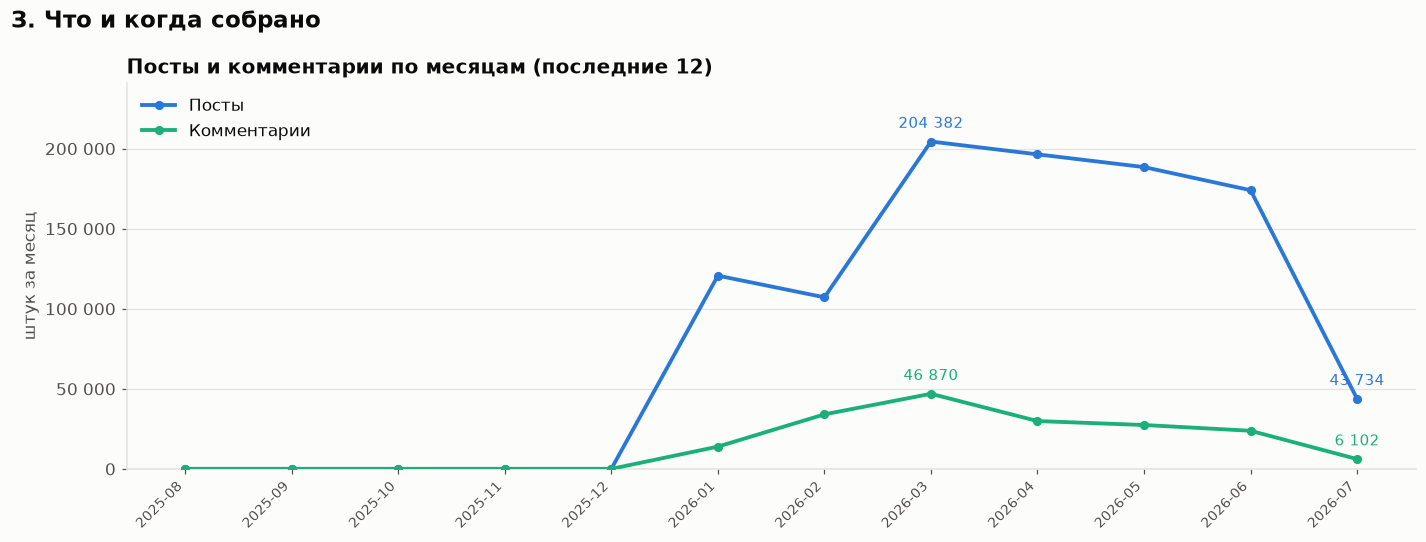

In [18]:
months_cache = CACHE/'posts_months.parquet'
if USE_CACHE and months_cache.exists():
    posts_m = pd.read_parquet(months_cache)
else:
    parts = []
    for chunk in pd.read_csv(DATA/'posts.csv', sep=';', chunksize=1_000_000,
                             usecols=['date'], on_bad_lines='skip', low_memory=False):
        m = chunk['date'].astype(str).str.slice(0, 7)          # 'YYYY-MM' без разбора timezone
        parts.append(m.value_counts())
    posts_m = (pd.concat(parts).groupby(level=0).sum().rename('posts').to_frame())
    posts_m.to_parquet(months_cache)

comm_m = pd.read_csv(DATA/'comments.csv', sep=';', usecols=['date'],
                     on_bad_lines='skip', low_memory=False)
comm_m = comm_m['date'].astype(str).str.slice(0, 7).value_counts().rename('comments').to_frame()

ts = posts_m.join(comm_m, how='outer').fillna(0)
ts = ts[ts.index.str.match(r'^\d{4}-\d{2}$')].sort_index()

# Ось должна быть НЕПРЕРЫВНОЙ по времени: в данных есть редкие старые комментарии
# (вплоть до 2011 г.), и если просто взять существующие месяцы, они встанут рядом с
# 2026-м и график соврёт. Берём последние 12 месяцев сплошным диапазоном.
last = pd.Period(ts.index.max(), freq='M')
full = pd.period_range(last - 11, last, freq='M').astype(str)
ts = ts.reindex(full).fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
xs = np.arange(len(ts))
ax.plot(xs, ts.posts, color=ORD, lw=2.5, marker='o', ms=5, zorder=3, label='Посты')
ax.plot(xs, ts.comments, color=ACC, lw=2.5, marker='o', ms=5, zorder=3, label='Комментарии')
ax.set_ylabel('штук за месяц')
ax.set_title('Посты и комментарии по месяцам (последние 12)', loc='left')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: rus(v)))
ax.set_xticks(xs); ax.set_xticklabels(ts.index, rotation=45, ha='right', fontsize=9)
ax.xaxis.grid(False)
ax.legend(loc='upper left')

# Подписи только на пиках и на последней точке — не на каждой
for col, color in (('posts', ORD), ('comments', ACC)):
    peak = int(ts[col].values.argmax())
    for i in {peak, len(ts)-1}:
        ax.annotate(rus(ts[col].iloc[i]), (i, ts[col].iloc[i]), textcoords='offset points',
                    xytext=(0, 9), ha='center', fontsize=9.5, color=color)

ax.set_ylim(0, ts.values.max()*1.18)
fig.suptitle('З. Что и когда собрано', x=0.005, ha='left', fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'H_timeline')

covered = ts[ts.posts > 0].index
print(f'посты собраны за: {covered.min()} … {covered.max()} '
      f'(нижняя граница — COLLECT_SINCE парсера)')

## И) Насколько широко разбросана аудитория

Сколько сообществ лайкает один человек. Если почти все сидят в одном паблике,
«региональная аудитория» — фикция из несвязанных кусков; если ядро пересекает
десятки сообществ, это действительно общая медийная аудитория региона.

сохранено: figures/I_breadth.png
медиана сообществ на человека: все — 1, ядро — 3


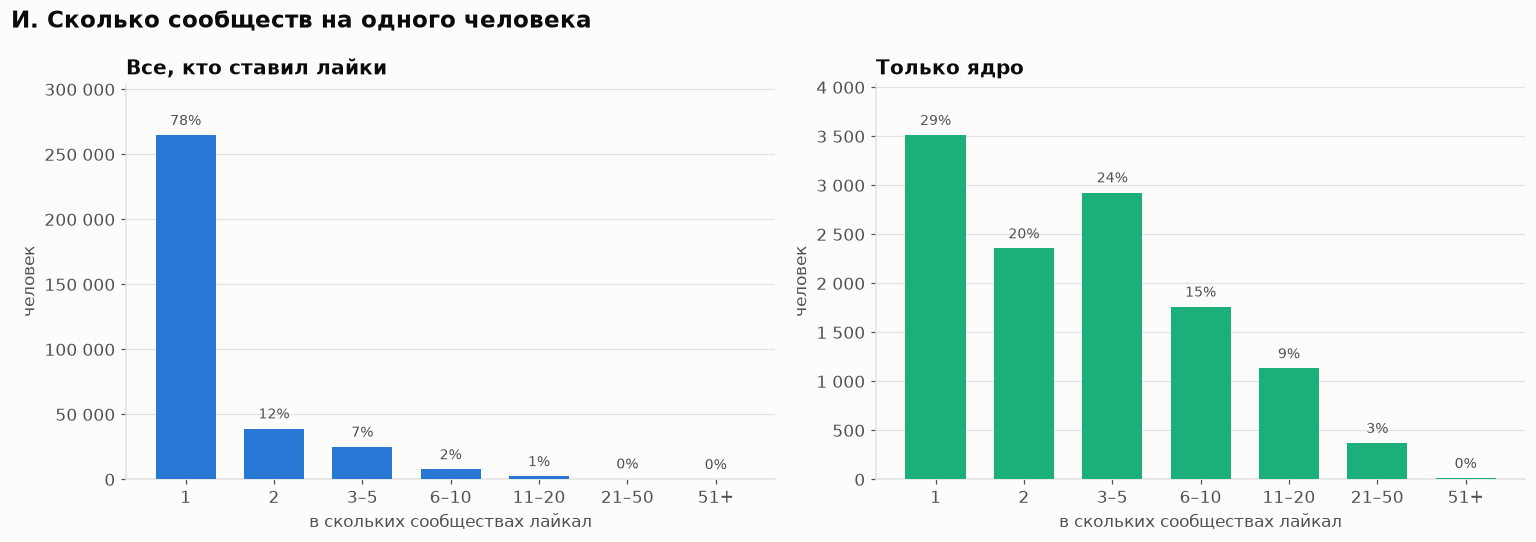

In [19]:
groups_per_user = likes.groupby('user_id').owner_id.nunique()
core_gpu = groups_per_user[groups_per_user.index.isin(core_ids)]

bins   = [1, 2, 3, 6, 11, 21, 51, np.inf]
labels = ['1', '2', '3–5', '6–10', '11–20', '21–50', '51+']
all_c  = pd.cut(groups_per_user, bins=bins, labels=labels, right=False).value_counts().reindex(labels)
core_c = pd.cut(core_gpu,        bins=bins, labels=labels, right=False).value_counts().reindex(labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
xx = np.arange(len(labels))

b1 = ax1.bar(xx, all_c.values, color=ORD, width=0.68, zorder=3)
ax1.set_title('Все, кто ставил лайки', loc='left')
ax1.set_xlabel('в скольких сообществах лайкал'); ax1.set_ylabel('человек')
ax1.set_xticks(xx); ax1.set_xticklabels(labels); ax1.xaxis.grid(False)
ax1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: rus(v)))
for b, v in zip(b1, all_c.values):
    ax1.text(b.get_x()+b.get_width()/2, v + all_c.max()*0.02,
             f'{v/all_c.sum():.0%}', ha='center', va='bottom', fontsize=9, color=INK2)
ax1.set_ylim(0, all_c.max()*1.15)

b2 = ax2.bar(xx, core_c.values, color=ACC, width=0.68, zorder=3)
ax2.set_title('Только ядро', loc='left')
ax2.set_xlabel('в скольких сообществах лайкал'); ax2.set_ylabel('человек')
ax2.set_xticks(xx); ax2.set_xticklabels(labels); ax2.xaxis.grid(False)
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: rus(v)))
for b, v in zip(b2, core_c.values):
    ax2.text(b.get_x()+b.get_width()/2, v + core_c.max()*0.02,
             f'{v/max(core_c.sum(),1):.0%}', ha='center', va='bottom', fontsize=9, color=INK2)
ax2.set_ylim(0, core_c.max()*1.15)

fig.suptitle('И. Сколько сообществ на одного человека', x=0.005, ha='left',
             fontsize=15, fontweight='semibold')
fig.tight_layout()
save(fig, 'I_breadth')

print(f'медиана сообществ на человека: все — {groups_per_user.median():.0f}, '
      f'ядро — {core_gpu.median():.0f}')